## Data loading

In [ ]:
import pandas as pd

df = pd.read_csv('password_Set1.csv')
print(df.shape)

(30050, 2)


## Data characteristics.


Password Strength Distribution:
strength
0     5000
1    10000
2    10000
3       50
4     5000
Name: count, dtype: int64


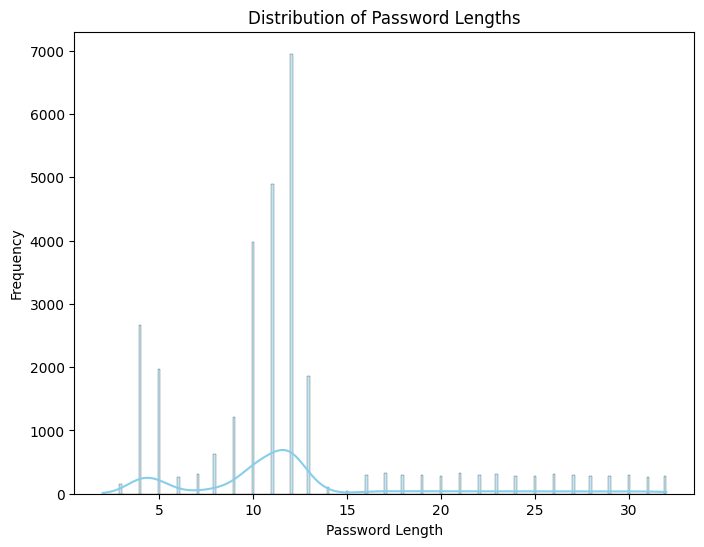

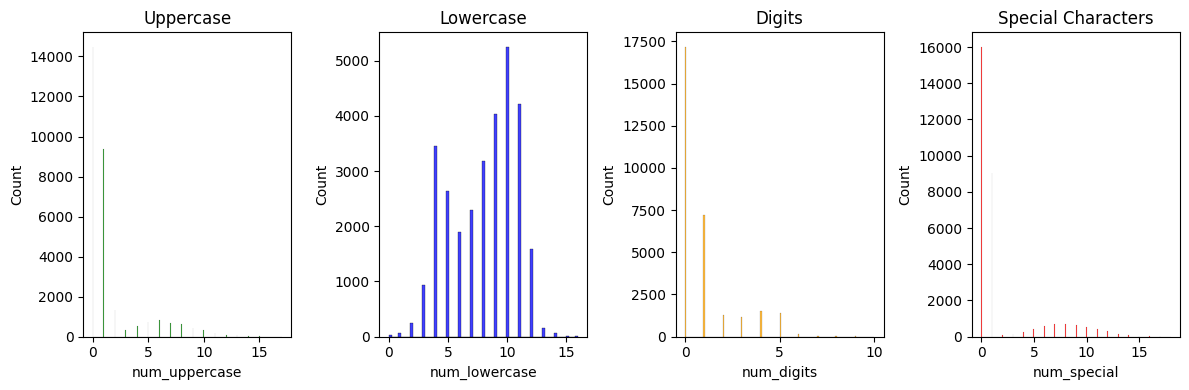

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Password Strength Distribution
strength_counts = df['strength'].value_counts().sort_index()
print("\nPassword Strength Distribution:")
print(strength_counts)

# Password Length to Strength
df['password_length'] = df['password'].str.len()
plt.figure(figsize=(8, 6))
sns.histplot(df['password_length'], kde=True, color='skyblue')
plt.title('Distribution of Password Lengths')
plt.xlabel('Password Length')
plt.ylabel('Frequency')
plt.show()

# Character Type distribution
df['num_uppercase'] = df['password'].str.findall(r'[A-Z]').str.len()
df['num_lowercase'] = df['password'].str.findall(r'[a-z]').str.len()
df['num_digits'] = df['password'].str.findall(r'[0-9]').str.len()
df['num_special'] = df['password'].str.findall(r'[^a-zA-Z0-9]').str.len()

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
sns.histplot(df['num_uppercase'], kde=False, color="green")
plt.title('Uppercase')
plt.subplot(1, 4, 2)
sns.histplot(df['num_lowercase'], kde=False, color="blue")
plt.title('Lowercase')
plt.subplot(1, 4, 3)
sns.histplot(df['num_digits'], kde=False, color="orange")
plt.title('Digits')
plt.subplot(1, 4, 4)
sns.histplot(df['num_special'], kde=False, color="red")
plt.title('Special Characters')
plt.tight_layout()
plt.show()

## Data vectorization

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['password'])

# Target Variable
y = df['strength']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (24040, 5000)
X_test shape: (6010, 5000)
y_train shape: (24040,)
y_test shape: (6010,)


## New features from the password data


In [ ]:
import re
from scipy.sparse import hstack

# Calculate password length
df['length'] = df['password'].str.len()

# Count character types
df['uppercase'] = df['password'].str.count(r'[A-Z]')
df['lowercase'] = df['password'].str.count(r'[a-z]')
df['digits'] = df['password'].str.count(r'[0-9]')
df['special_chars'] = df['password'].str.count(r'[^a-zA-Z0-9]')

# Calculate character type ratios
df['uppercase_ratio'] = df['uppercase'] / df['length']
df['lowercase_ratio'] = df['lowercase'] / df['length']
df['digit_ratio'] = df['digits'] / df['length']
df['special_char_ratio'] = df['special_chars'] / df['length']

# Handle potential division by zero
df.fillna(0, inplace=True)

# Convert new features to sparse matrix
from scipy.sparse import csr_matrix
new_features = df[['length', 'uppercase', 'lowercase', 'digits', 'special_chars', 'uppercase_ratio', 'lowercase_ratio', 'digit_ratio', 'special_char_ratio']]
new_features_sparse = csr_matrix(new_features)

# Link with TF-IDF features (assuming X is the TF-IDF matrix from previous steps)
X_extended = hstack([X, new_features_sparse])

print(f"Shape of extended feature matrix X_extended: {X_extended.shape}")

Shape of extended feature matrix X_extended: (30050, 5009)


## Model training

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming X_extended and y are defined from previous steps
X_train, X_test, y_train, y_test = train_test_split(X_extended, y, test_size=0.2, random_state=42)

# Initialize the kNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the kNN classifier
knn_model.fit(X_train, y_train)

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest classifier
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model evaluation

### Subtask:
Evaluate the performance of the trained kNN and Random Forest models.


kNN Model Evaluation:
Accuracy: 0.9692179700499168
Precision: 0.9819150287853663
Recall: 0.8267000024010368
F1-score: 0.8543129293741523

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       982
           1       0.92      0.99      0.96      2002
           2       0.99      0.92      0.96      2020
           3       1.00      0.22      0.36         9
           4       1.00      1.00      1.00       997

    accuracy                           0.97      6010
   macro avg       0.98      0.83      0.85      6010
weighted avg       0.97      0.97      0.97      6010



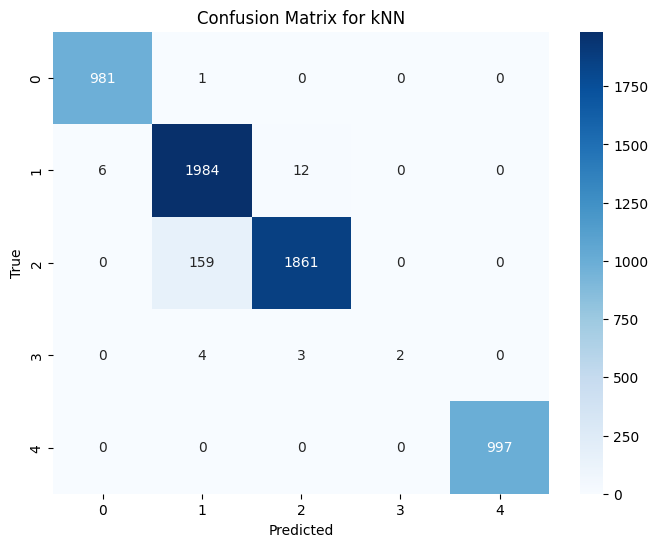


Random Forest Model Evaluation:
Accuracy: 0.9695507487520799
Precision: 0.9822285252574879
Recall: 0.8710406809576015
F1-score: 0.9047612055649601

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       982
           1       0.92      0.99      0.96      2002
           2       0.99      0.92      0.96      2020
           3       1.00      0.44      0.62         9
           4       1.00      1.00      1.00       997

    accuracy                           0.97      6010
   macro avg       0.98      0.87      0.90      6010
weighted avg       0.97      0.97      0.97      6010



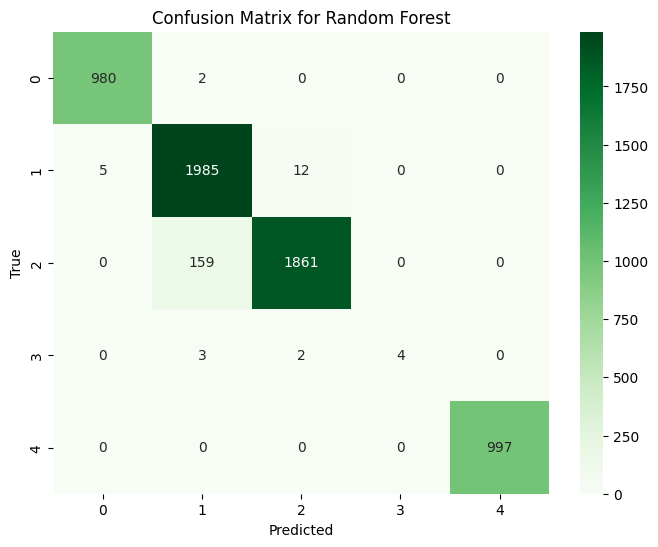

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict using kNN
knn_predictions = knn_model.predict(X_test)

# Predict using Random Forest
rf_predictions = rf_model.predict(X_test)

# Evaluate kNN
print("kNN Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, knn_predictions)}")
print(f"Precision: {precision_score(y_test, knn_predictions, average='macro')}")
print(f"Recall: {recall_score(y_test, knn_predictions, average='macro')}")
print(f"F1-score: {f1_score(y_test, knn_predictions, average='macro')}")
print("\nClassification Report:")
print(classification_report(y_test, knn_predictions))

# Confusion Matrix for kNN
knn_cm = confusion_matrix(y_test, knn_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for kNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Evaluate Random Forest
print("\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions)}")
print(f"Precision: {precision_score(y_test, rf_predictions, average='macro')}")
print(f"Recall: {recall_score(y_test, rf_predictions, average='macro')}")
print(f"F1-score: {f1_score(y_test, rf_predictions, average='macro')}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Password Checker ver 3
added user recommendation

In [ ]:
import numpy as np
from scipy.sparse import hstack, csr_matrix
import ipywidgets as widgets
from IPython.display import display

# Define the helper function first
def _extract_features(password, vectorizer):
    """Extracts TF-IDF and engineered features from a single password."""
    # Ensure password is a string
    if not isinstance(password, str):
        password = str(password)

    # 1. TF-IDF Features
    tfidf_features = vectorizer.transform([password])  # Shape: (1, 5000)

    # 2. Engineered Features
    length = len(password)
    uppercase = sum(c.isupper() for c in password)
    lowercase = sum(c.islower() for c in password)
    digits = sum(c.isdigit() for c in password)
    special_chars = sum(not c.isalnum() for c in password)

    # Calculate ratios, avoiding division by zero
    if length > 0:
        uppercase_ratio = uppercase / length
        lowercase_ratio = lowercase / length
        digit_ratio = digits / length
        special_char_ratio = special_chars / length
    else:
        uppercase_ratio = 0
        lowercase_ratio = 0
        digit_ratio = 0
        special_char_ratio = 0

    # Create a 2D array for engineered features
    engineered_features = np.array([[length, uppercase, lowercase, digits, special_chars,
                                    uppercase_ratio, lowercase_ratio, digit_ratio, special_char_ratio]])

    # Convert to sparse matrix
    engineered_features_sparse = csr_matrix(engineered_features)  # Shape: (1, 9)

    # Combine Features: TF-IDF features (1, 5000) + engineered features (1, 9)
    combined_features = hstack([tfidf_features, engineered_features_sparse])  # Shape: (1, 5009)
    return combined_features

# Define predict_password_strength_knn (uses _extract_features)
def predict_password_strength_knn(password, vectorizer, knn_model):
    password_features = _extract_features(password, vectorizer)
    predicted_strength = knn_model.predict(password_features)[0]
    return predicted_strength

# Define predict_password_strength_rf (uses _extract_features)
def predict_password_strength_rf(password, vectorizer, rf_model):
    password_features = _extract_features(password, vectorizer)
    predicted_strength = rf_model.predict(password_features)[0]
    return predicted_strength

# Define on_submit (uses the two prediction functions)
def on_submit(change):
    with output:
        output.clear_output()
        password = change['new']
        try:
            knn_prediction = predict_password_strength_knn(password, vectorizer, knn_model)
            rf_prediction = predict_password_strength_rf(password, vectorizer, best_rf_model)
            combined_prediction = round((0.4 * knn_prediction) + (0.6 * rf_prediction))

            # Print predictions
            print(f"Password: {password}")
            print(f"kNN Prediction: {knn_prediction}")
            print(f"Random Forest Prediction: {rf_prediction}")
            print(f"Combined Prediction: {combined_prediction}\n")

            # Determine suggestions based on predictions
            suggestion = ""

            # Check individual predictions and build suggestions accordingly
            if knn_prediction < 3:
                suggestion += "consider making your password longer.\n"
            if rf_prediction < 3:
                suggestion += ("consider using complex notations \n"
                         "ie.numbers (0-9), and signs like !@#$%^&*(){}|]\\<>?,./:\";'~\n")

            if knn_prediction >= 3 and rf_prediction >= 3:
                suggestion = "Your password is strong enough to use!"

            print(suggestion)
        except Exception as e:
            print(f"Error: {e}")

# Set up the widget
password_input = widgets.Text(
    placeholder='Enter your password here',
    description='Password:',
    disabled=False
)

output = widgets.Output()

# Attach the on_submit function to the widget
password_input.observe(on_submit, names='value')

# Display the widget
display(password_input, output)


Text(value='', description='Password:', placeholder='Enter your password here')

Output()